# Scam Website Prediction (Final - With Scoring Visualization)
Hybrid ML + Rule-Based Detection System

In [244]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlparse

from src.scraper import WebsiteScraper
from src.url_features import URLFeatureExtractor
from src.domain_features import DomainFeatureExtractor
from src.content_features import ContentFeatureExtractor

In [245]:
# Load model
MODEL_PATH = './pkl_models'
model = joblib.load(f'{MODEL_PATH}/random_forest.pkl')
feature_columns = joblib.load(f'{MODEL_PATH}/feature_columns.pkl')
print('Model loaded')

Model loaded


In [246]:
scraper = WebsiteScraper()
url_ext = URLFeatureExtractor()
domain_ext = DomainFeatureExtractor()
content_ext = ContentFeatureExtractor()

In [247]:
def build_vector(features):
    df = pd.DataFrame([features])
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    for col in feature_columns:
        if col not in df.columns:
            df[col] = 0

    return df[feature_columns]

In [248]:
def extract_features(url):
    data = scraper.scrape(url)

    final_url = data.get("final_url", url)

    features = {}
    features.update(url_ext.extract(final_url))
    features.update(domain_ext.extract(final_url))
    features.update(content_ext.extract(
        data.get('title'),
        data.get('text'),
        data.get('html')
    ))

    features['digit_ratio'] = features.get('num_digits',0)/(features.get('url_length',1))
    features['hyphen_ratio'] = features.get('num_hyphen',0)/(features.get('url_length',1))
    features['many_subdomains'] = int(features.get('subdomains',0) >= 3)
    features['is_long_url'] = int(features.get('url_length',0) > 75)

    return features, final_url

In [249]:
from urllib.parse import urlparse
import matplotlib.pyplot as plt

def predict(url):

    if not url.startswith(('http://','https://')):
        url = 'https://' + url

    print('\n' + '='*60)
    print(f"[INFO] Processing URL: {url}")
    print('='*60)

    # ================= SCRAPE =================
    data = scraper.scrape(url)
    final_url = data.get("final_url", url)
    domain = urlparse(final_url).netloc.lower()

    # ================= FEATURES =================
    features = {}
    features.update(url_ext.extract(final_url))
    features.update(domain_ext.extract(final_url))
    features.update(content_ext.extract(
        data.get("title"),
        data.get("text"),
        data.get("html")
    ))

    X = build_vector(features)
    base_proba = model.predict_proba(X)[0][1]

    scam_score = 0
    legit_boost = 0
    reasons = []

    # ================= TRUST SIGNALS =================

    trusted_domains = ['.edu', '.gov', '.ac.', '.org', '.mx']

    is_trusted = any(td in domain for td in trusted_domains)

    if is_trusted:
        legit_boost += 0.40
        reasons.append("Trusted domain")

    age = features.get('domain_age_days', 0)
    if age and age > 1000:
        legit_boost += 0.05   # reduced weight
        reasons.append("Old domain")

    # ================= SHORTENED URL =================

    is_short_url = False

    if features.get('is_shortened') == 1:
        is_short_url = True
        scam_score += 0.25
        reasons.append("Shortened URL")

    # ================= HOSTING DOMAIN DETECTION =================

    hosting_domains = [
        "wpenginepowered", "herokuapp", "firebaseapp",
        "github.io", "netlify", "vercel", "000webhost"
    ]

    if any(h in domain for h in hosting_domains):
        scam_score += 0.30
        reasons.append("Suspicious hosting domain")

    # ================= SCAM SIGNALS =================

    if features.get('num_hyphen',0) >= 5:
        scam_score += 0.15
        reasons.append("Excessive hyphens")

    if features.get('subdomains',0) >= 3:
        scam_score += 0.15
        reasons.append("Too many subdomains")

    if features.get('suspicious_tld') == 1:
        scam_score += 0.20
        reasons.append("Suspicious TLD")

    if any(h in domain for h in ['weebly','blogspot','wixsite','wordpress']):
        scam_score += 0.25
        reasons.append("Free hosting domain")

    if features.get('https') == 0:
        scam_score += 0.05
        reasons.append("No HTTPS")

    if features.get('url_length',0) > 80:
        scam_score += 0.05
        reasons.append("Very long URL")

    # ================= PATH-BASED PHISHING =================

    suspicious_paths = ["login", "verify", "account", "update", "secure", "wp-admin"]

    if any(p in final_url.lower() for p in suspicious_paths):
        scam_score += 0.20
        reasons.append("Suspicious path keywords")

    # ================= CONTENT SIGNALS =================

    if features.get("scam_keyword_density", 0) > 0.05:
        scam_score += 0.15
        reasons.append("High scam keyword density")

    if features.get("has_form") == 1 and not is_trusted:
        scam_score += 0.05
        reasons.append("Form present")

    if features.get("has_iframe") == 1 and not is_trusted:
        scam_score += 0.05
        reasons.append("Iframe detected")

    # ================= FINAL PROBABILITY =================

    final_proba = (0.85 * base_proba) + scam_score - legit_boost
    final_proba = max(0.0, min(1.0, final_proba))

    # 🔥 TRUST SAFETY NET
    if is_trusted:
        final_proba = min(final_proba, 0.45)

    # ================= DECISION =================

    if is_short_url:
        label = "⚠️ SUSPICIOUS (Shortened URL)"
        final_proba = max(final_proba, 0.65)

    elif final_proba >= 0.80:
        label = "🚨 SCAM (HIGH RISK)"

    elif final_proba >= 0.60:
        label = "⚠️ SUSPICIOUS"

    else:
        label = "✅ LEGIT"

    # ================= OUTPUT =================

    print("\n===== RESULT =====")
    print(f"Prediction           : {label}")
    print(f"Final Probability    : {final_proba:.4f}")
    print(f"Base ML Probability  : {base_proba:.4f}")

    print("\n===== ANALYSIS =====")
    print(f"Domain            : {domain}")
    print(f"HTTPS             : {features.get('https')}")
    print(f"Domain Age        : {features.get('domain_age_days')}")
    print(f"URL Length        : {features.get('url_length')}")
    print(f"Subdomains        : {features.get('subdomains')}")

    print("\n[Reasons]")
    for r in reasons:
        print("-", r)

    print("="*60)

    # ================= VISUALIZATION =================

    plt.figure()
    plt.bar(['ML Base','Scam Score','Legit Boost','Final'],
            [base_proba, scam_score, legit_boost, final_proba])
    plt.title('Decision Breakdown')
    plt.ylabel('Score')
    plt.show()

    return label, final_proba


[INFO] Processing URL: https://www.gtu.ac.in
[DEBUG] Expanded URL: https://www.gtu.ac.in

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3395
Base ML Probability  : 0.8700

===== ANALYSIS =====
Domain            : www.gtu.ac.in
HTTPS             : 1
Domain Age        : None
URL Length        : 22
Subdomains        : 2

[Reasons]
- Trusted domain


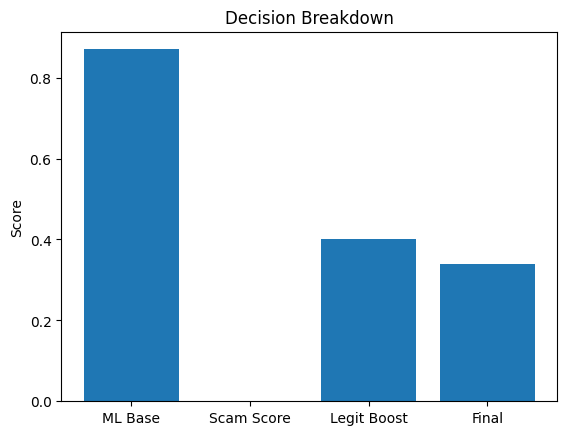

('✅ LEGIT', np.float64(0.3394999999999999))

In [250]:
# Test
predict('https://www.gtu.ac.in')


[INFO] Processing URL: https://www.spectricssolutions.com/
[DEBUG] Expanded URL: https://www.spectricssolutions.com/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.5922
Base ML Probability  : 0.6967

===== ANALYSIS =====
Domain            : www.spectricssolutions.com
HTTPS             : 1
Domain Age        : 2205
URL Length        : 35
Subdomains        : 1

[Reasons]
- Old domain
- Form present


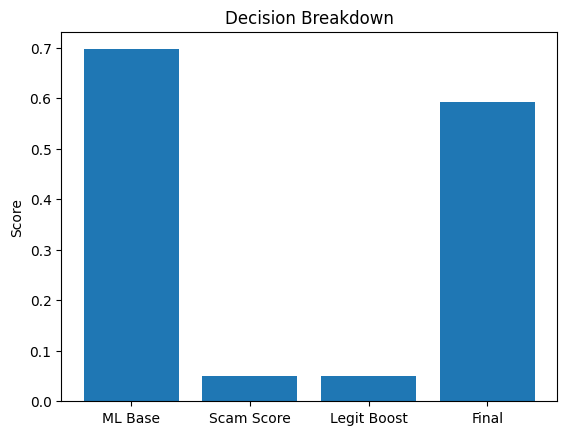

('✅ LEGIT', np.float64(0.5921666666666666))

In [251]:
predict('https://www.spectricssolutions.com/')



[INFO] Processing URL: https://b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com
[DEBUG] Expanded URL: https://b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.9082
Base ML Probability  : 0.6567

===== ANALYSIS =====
Domain            : b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com
HTTPS             : 1
Domain Age        : 4850
URL Length        : 49
Subdomains        : 1

[Reasons]
- Old domain
- Excessive hyphens
- Free hosting domain


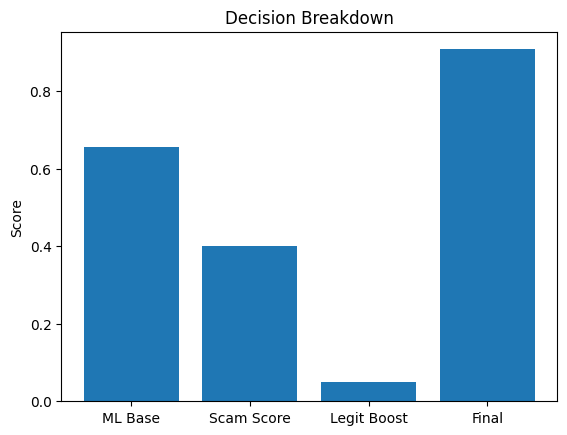

('🚨 SCAM (HIGH RISK)', np.float64(0.9081666666666666))

In [252]:
predict('b-t-i-n-t-e-r-n-e-t-105959.weeblysite.com')



[INFO] Processing URL: https://tinyurl.com/ymb5eep9
[DEBUG] Expanded URL: https://tinyurl.com/app/nospam/tinyurl.com/ymb5eep9

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS (Shortened URL)
Final Probability    : 0.6500
Base ML Probability  : 0.2233

===== ANALYSIS =====
Domain            : tinyurl.com
HTTPS             : 1
Domain Age        : 8828
URL Length        : 51
Subdomains        : 0

[Reasons]
- Old domain
- Shortened URL


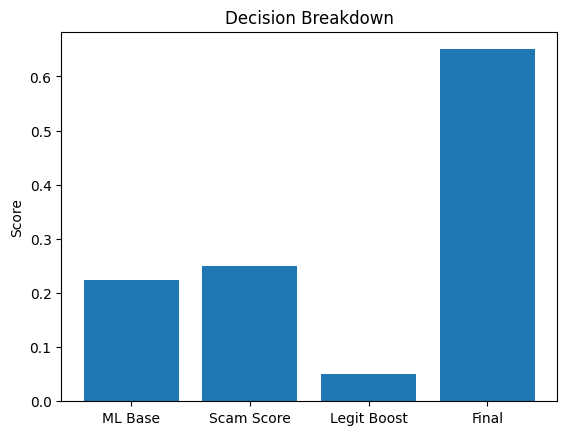

('⚠️ SUSPICIOUS (Shortened URL)', 0.65)

In [253]:
predict('https://tinyurl.com/ymb5eep9')



[INFO] Processing URL: https://www.harvard.edu
[DEBUG] Expanded URL: https://www.harvard.edu

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3140
Base ML Probability  : 0.8400

===== ANALYSIS =====
Domain            : www.harvard.edu
HTTPS             : 1
Domain Age        : None
URL Length        : 24
Subdomains        : 1

[Reasons]
- Trusted domain


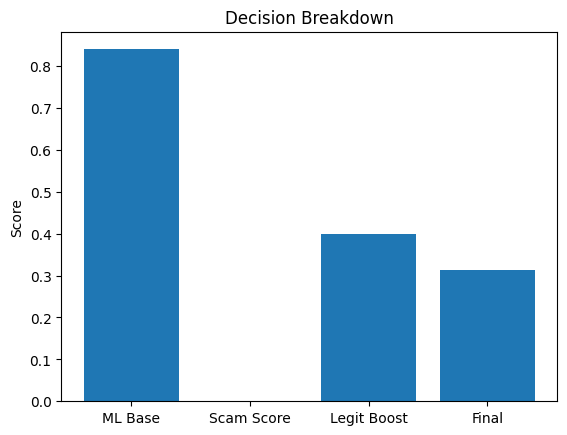

('✅ LEGIT', np.float64(0.31399999999999995))

In [254]:
predict('https://www.harvard.edu')



[INFO] Processing URL: https://www.microsoft.com
[DEBUG] Expanded URL: https://www.microsoft.com

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.4448
Base ML Probability  : 0.5233

===== ANALYSIS =====
Domain            : www.microsoft.com
HTTPS             : 1
Domain Age        : 12752
URL Length        : 26
Subdomains        : 1

[Reasons]
- Old domain
- Form present


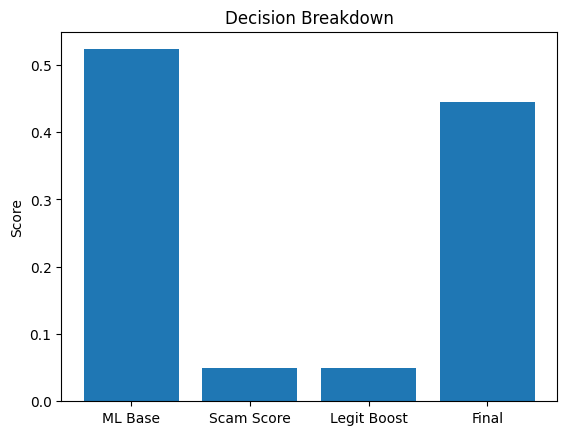

('✅ LEGIT', np.float64(0.4448333333333333))

In [255]:
predict('https://www.microsoft.com')



[INFO] Processing URL: https://www.tcs.com
[DEBUG] Expanded URL: https://www.tcs.com

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.4798
Base ML Probability  : 0.6233

===== ANALYSIS =====
Domain            : www.tcs.com
HTTPS             : 1
Domain Age        : 10352
URL Length        : 19
Subdomains        : 1

[Reasons]
- Old domain


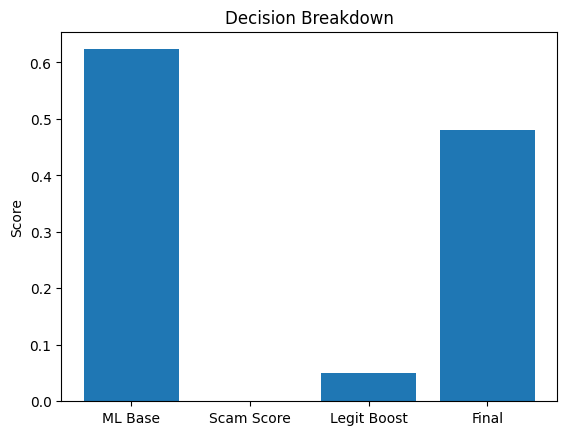

('✅ LEGIT', np.float64(0.4798333333333333))

In [256]:
predict('https://www.tcs.com')



[INFO] Processing URL: https://t.co/example
[DEBUG] Expanded URL: https://t.co/example

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS (Shortened URL)
Final Probability    : 0.9753
Base ML Probability  : 0.8533

===== ANALYSIS =====
Domain            : t.co
HTTPS             : 1
Domain Age        : None
URL Length        : 20
Subdomains        : 0

[Reasons]
- Shortened URL


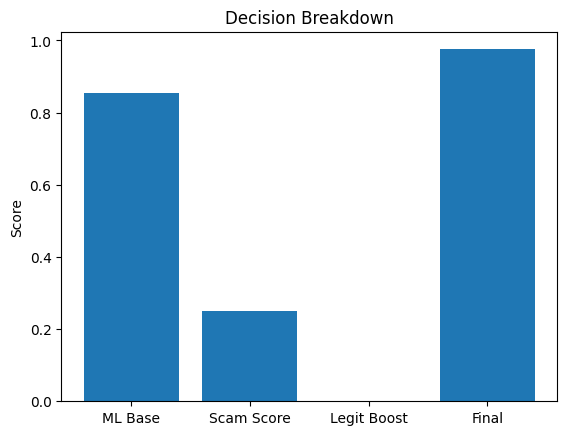

('⚠️ SUSPICIOUS (Shortened URL)', np.float64(0.9753333333333334))

In [257]:
predict('https://t.co/example')



[INFO] Processing URL: https://paypal-login-help.com
[DEBUG] Expanded URL: https://paypal-login-help.com

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.9763
Base ML Probability  : 0.9133

===== ANALYSIS =====
Domain            : paypal-login-help.com
HTTPS             : 1
Domain Age        : None
URL Length        : 29
Subdomains        : 0

[Reasons]
- Suspicious path keywords


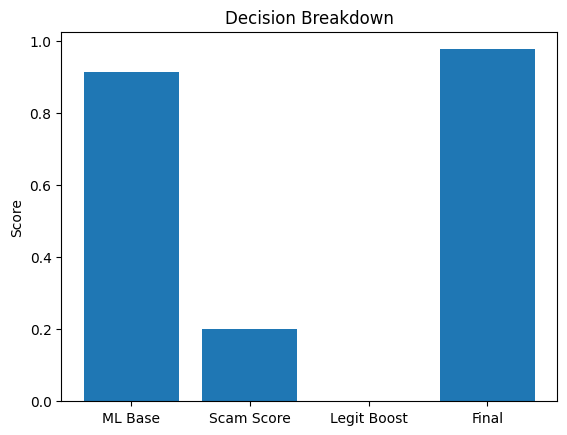

('🚨 SCAM (HIGH RISK)', np.float64(0.9763333333333333))

In [258]:
predict('https://paypal-login-help.com')



[INFO] Processing URL: http://account-check.ga
[DEBUG] Expanded URL: http://account-check.ga

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9700

===== ANALYSIS =====
Domain            : account-check.ga
HTTPS             : 0
Domain Age        : None
URL Length        : 23
Subdomains        : 0

[Reasons]
- Suspicious TLD
- No HTTPS
- Suspicious path keywords


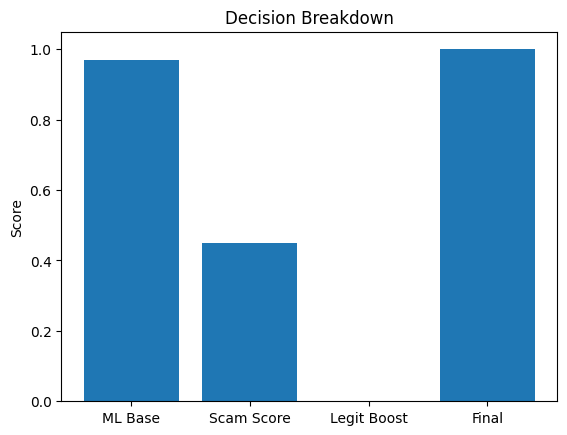

('🚨 SCAM (HIGH RISK)', 1.0)

In [259]:
predict('http://account-check.ga')



[INFO] Processing URL: https://docs.python.org
[DEBUG] Expanded URL: https://docs.python.org/3/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.0000
Base ML Probability  : 0.3800

===== ANALYSIS =====
Domain            : docs.python.org
HTTPS             : 1
Domain Age        : 11326
URL Length        : 26
Subdomains        : 1

[Reasons]
- Trusted domain
- Old domain


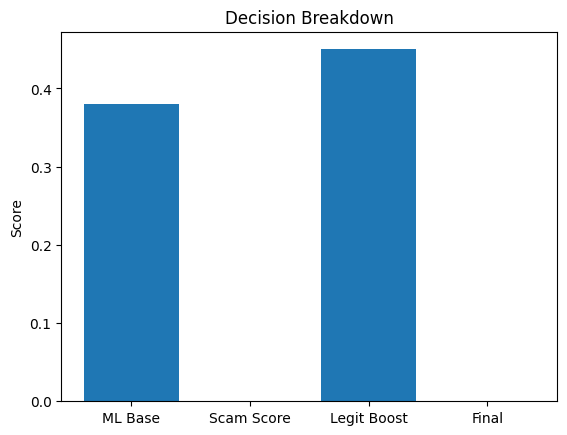

('✅ LEGIT', 0.0)

In [260]:
predict('https://docs.python.org')



[INFO] Processing URL: https://google-account-verification-alert.net
[DEBUG] Expanded URL: https://google-account-verification-alert.net

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.9735
Base ML Probability  : 0.9100

===== ANALYSIS =====
Domain            : google-account-verification-alert.net
HTTPS             : 1
Domain Age        : None
URL Length        : 45
Subdomains        : 0

[Reasons]
- Suspicious path keywords


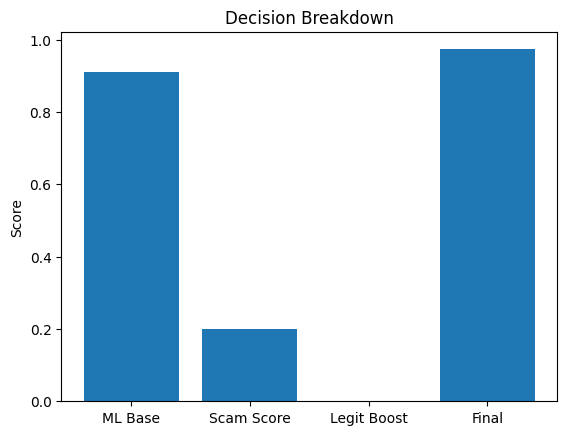

('🚨 SCAM (HIGH RISK)', np.float64(0.9735))

In [261]:
predict('https://google-account-verification-alert.net')



[INFO] Processing URL: https://att-102546.weeblysite.com/
[DEBUG] Expanded URL: https://att-102546.weeblysite.com/

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.8120
Base ML Probability  : 0.7200

===== ANALYSIS =====
Domain            : att-102546.weeblysite.com
HTTPS             : 1
Domain Age        : 4850
URL Length        : 34
Subdomains        : 1

[Reasons]
- Old domain
- Free hosting domain


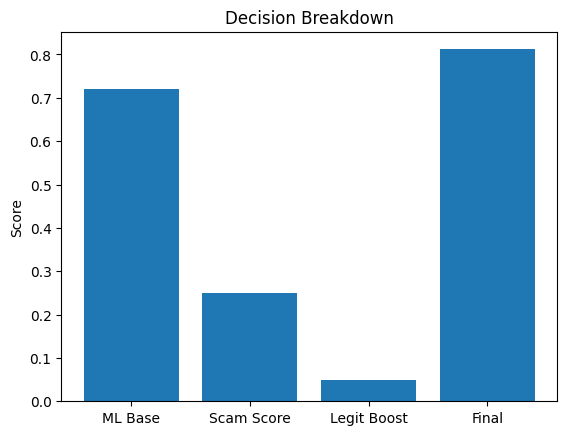

('🚨 SCAM (HIGH RISK)', np.float64(0.8119999999999999))

In [262]:
predict('https://att-102546.weeblysite.com/')


[INFO] Processing URL: https://m1csspartnero.wpenginepowered.com/wp-admin/js/pages/step-one.php
[DEBUG] Expanded URL: https://m1csspartnero.wpenginepowered.com/wp-admin/js/pages/step-one.php

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.8600

===== ANALYSIS =====
Domain            : m1csspartnero.wpenginepowered.com
HTTPS             : 1
Domain Age        : 2138
URL Length        : 72
Subdomains        : 1

[Reasons]
- Old domain
- Suspicious hosting domain
- Suspicious path keywords


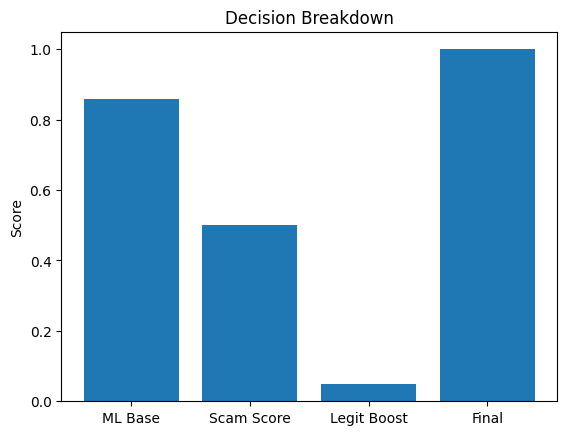

('🚨 SCAM (HIGH RISK)', 1.0)

In [263]:
predict('https://m1csspartnero.wpenginepowered.com/wp-admin/js/pages/step-one.php')



[INFO] Processing URL: https://urlz.fr/uMHD
[DEBUG] Expanded URL: https://urlz.fr/uMHD

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS
Final Probability    : 0.7027
Base ML Probability  : 0.8267

===== ANALYSIS =====
Domain            : urlz.fr
HTTPS             : 1
Domain Age        : None
URL Length        : 20
Subdomains        : 0

[Reasons]


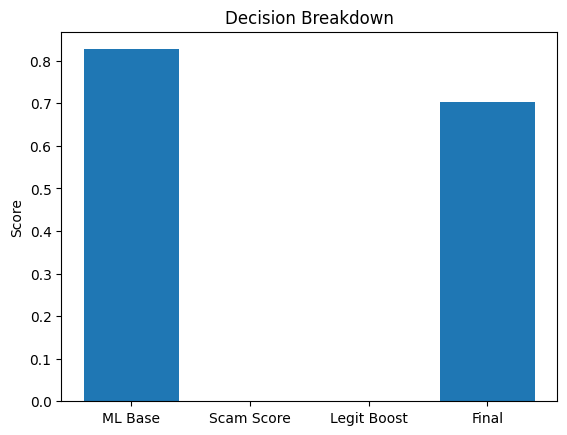

('⚠️ SUSPICIOUS', np.float64(0.7026666666666667))

In [264]:
predict('https://urlz.fr/uMHD')



[INFO] Processing URL: https://cy68861-wordpress-dupei.tw1.ru/wp-content/plugins/vsndd-jvca/vsndd-jvca/pages/region.php?lca#a92a2ef45c3d3895f
[DEBUG] Expanded URL: https://cy68861-wordpress-dupei.tw1.ru/wp-content/plugins/vsndd-jvca/vsndd-jvca/pages/region.php?lca#a92a2ef45c3d3895f

===== RESULT =====
Prediction           : ⚠️ SUSPICIOUS
Final Probability    : 0.7488
Base ML Probability  : 0.7633

===== ANALYSIS =====
Domain            : vh454.timeweb.ru
HTTPS             : 1
Domain Age        : None
URL Length        : 90
Subdomains        : 1

[Reasons]
- Very long URL
- Form present


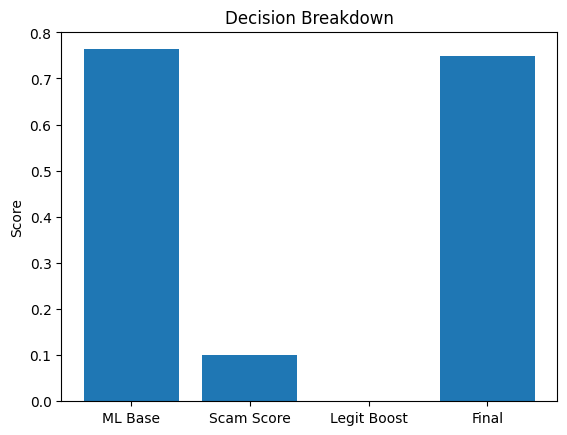

('⚠️ SUSPICIOUS', np.float64(0.7488333333333332))

In [265]:
predict('https://cy68861-wordpress-dupei.tw1.ru/wp-content/plugins/vsndd-jvca/vsndd-jvca/pages/region.php?lca#a92a2ef45c3d3895f')



[INFO] Processing URL: https://update-limited-offer.tk/free-money?campaign=n9uhjpkhf33g
[DEBUG] Expanded URL: https://update-limited-offer.tk/free-money?campaign=n9uhjpkhf33g

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 1.0000
Base ML Probability  : 0.9167

===== ANALYSIS =====
Domain            : update-limited-offer.tk
HTTPS             : 1
Domain Age        : None
URL Length        : 64
Subdomains        : 0

[Reasons]
- Suspicious TLD
- Suspicious path keywords


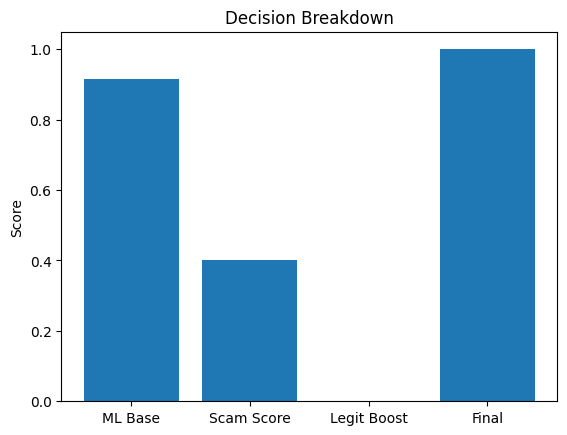

('🚨 SCAM (HIGH RISK)', 1.0)

In [266]:
predict('https://update-limited-offer.tk/free-money?campaign=n9uhjpkhf33g')



[INFO] Processing URL: http://www.ippt.pan.pl/en/
[DEBUG] Expanded URL: http://www.ippt.pan.pl/en/

===== RESULT =====
Prediction           : 🚨 SCAM (HIGH RISK)
Final Probability    : 0.8122
Base ML Probability  : 0.8967

===== ANALYSIS =====
Domain            : www.ippt.pan.pl
HTTPS             : 0
Domain Age        : None
URL Length        : 26
Subdomains        : 2

[Reasons]
- No HTTPS


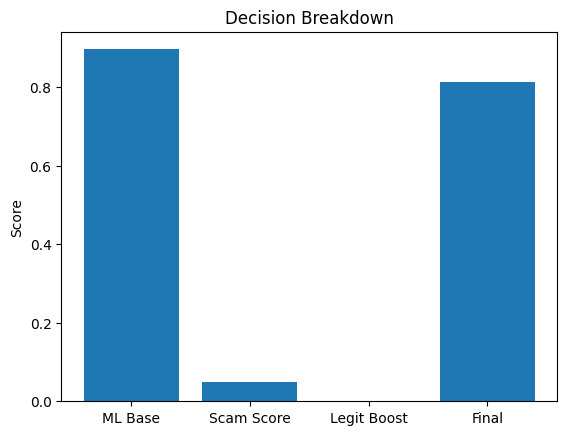

('🚨 SCAM (HIGH RISK)', np.float64(0.8121666666666666))

In [267]:
predict('http://www.ippt.pan.pl/en/')


In [268]:
# predict('http://www2.st.com/content/st_com/en.html')



[INFO] Processing URL: http://www.uam.mx/
[DEBUG] Expanded URL: https://www.uam.mx/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3593
Base ML Probability  : 0.8933

===== ANALYSIS =====
Domain            : www.uam.mx
HTTPS             : 1
Domain Age        : None
URL Length        : 19
Subdomains        : 1

[Reasons]
- Trusted domain


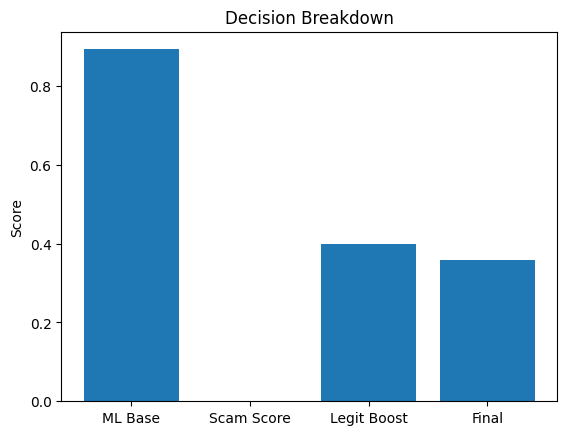

('✅ LEGIT', np.float64(0.3593333333333333))

In [269]:
predict('http://www.uam.mx/')



[INFO] Processing URL: http://www.westminster.ac.uk/
[DEBUG] Expanded URL: https://www.westminster.ac.uk/

===== RESULT =====
Prediction           : ✅ LEGIT
Final Probability    : 0.3367
Base ML Probability  : 0.8667

===== ANALYSIS =====
Domain            : www.westminster.ac.uk
HTTPS             : 1
Domain Age        : None
URL Length        : 30
Subdomains        : 2

[Reasons]
- Trusted domain


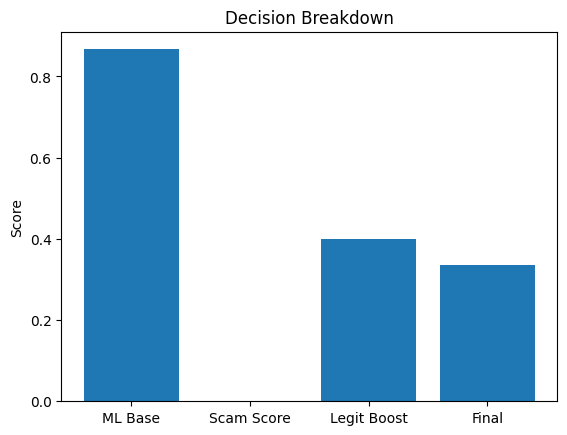

('✅ LEGIT', np.float64(0.33666666666666667))

In [270]:
predict('http://www.westminster.ac.uk/')
